# Autoresearch: Cross-Method Comparison

Reads all `results/**/results.tsv` files and compares methods (baseline, chaos, etc.).

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

ROOT = Path(".")

# Load all results.tsv files, tagging each with method name from parent directory
# Expected structure: <method>/results.tsv
frames = []
for tsv_path in sorted(ROOT.glob("*/results.tsv")):
    method = tsv_path.parent.name
    df = pd.read_csv(tsv_path, sep="\t")
    df["method"] = method
    df["run_id"] = method  # single run per method for now
    df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
    df["best_val_bpb"] = pd.to_numeric(df["best_val_bpb"], errors="coerce")
    df["iter"] = pd.to_numeric(df["iter"], errors="coerce")
    frames.append(df)

if not frames:
    raise FileNotFoundError("No results.tsv files found in any subdirectory")

all_df = pd.concat(frames, ignore_index=True)
methods = sorted(all_df["method"].unique())
print(f"Loaded {len(all_df)} experiments across {len(methods)} method(s): {methods}")
print(f"Runs per method: {all_df.groupby('method')['run_id'].nunique().to_dict()}")

Loaded 96 experiments across 1 method(s): ['mad-scientist']
Runs per method: {'mad-scientist': 1}


## 1. Envelope Plot: Best val_bpb vs Iteration

The primary metric. Each line is one run; the y-axis shows the best val_bpb achieved so far at each iteration.

In [ ]:
METHOD_COLORS = {
    "baseline": "#2ecc71",
    "chaos": "#e74c3c",
    "mad-scientist-3-11": "#9b59b6",
}

def color_for(method):
    return METHOD_COLORS.get(method, f"C{hash(method) % 10}")

fig, ax = plt.subplots(figsize=(14, 7))

for method in methods:
    method_df = all_df[all_df["method"] == method]
    runs = sorted(method_df["run_id"].unique())
    for i, run_id in enumerate(runs):
        run_df = method_df[method_df["run_id"] == run_id].sort_values("iter")
        label = f"{method}" if i == 0 else None
        ax.plot(
            run_df["iter"], run_df["best_val_bpb"],
            color=color_for(method), alpha=0.7, linewidth=1.5,
            label=label,
        )

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Best val_bpb (lower is better)", fontsize=12)
ax.set_title("Envelope: Best val_bpb Over Time by Method", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("envelope.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Terminal Performance: Best val_bpb per Run

Box plot of the best val_bpb each run achieved, grouped by method.

/var/folders/ld/h3hbldbd4_16kqkgv5fmyzph0000gn/T/ipykernel_49897/2375626574.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, labels=methods, patch_artist=True, widths=0.5)


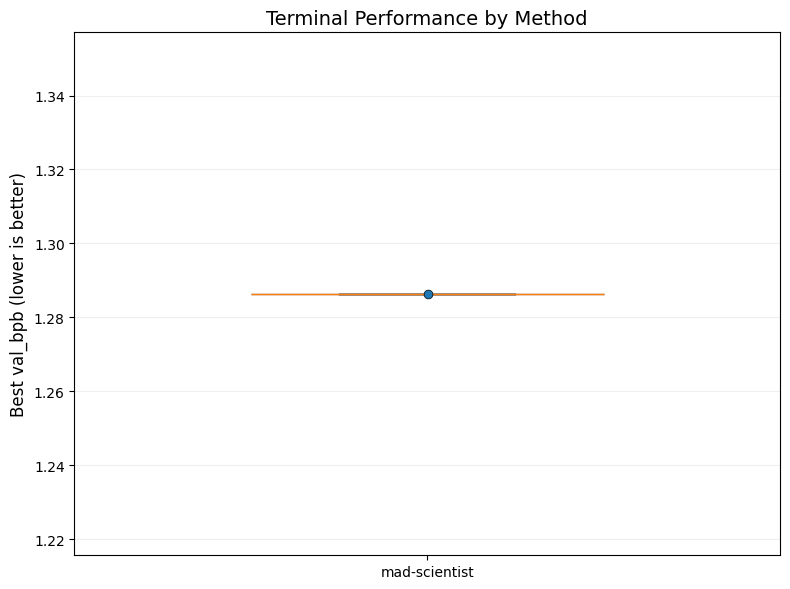

               count      mean  std       min       25%       50%       75%  \
method                                                                        
mad-scientist    1.0  1.286357  NaN  1.286357  1.286357  1.286357  1.286357   

                    max  
method                   
mad-scientist  1.286357  


In [10]:
terminal = (
    all_df.groupby(["method", "run_id"])["best_val_bpb"]
    .min()
    .reset_index()
    .rename(columns={"best_val_bpb": "terminal_bpb"})
)

fig, ax = plt.subplots(figsize=(8, 6))
data_by_method = [terminal[terminal["method"] == m]["terminal_bpb"].values for m in methods]
bp = ax.boxplot(data_by_method, labels=methods, patch_artist=True, widths=0.5)
for patch, method in zip(bp["boxes"], methods):
    patch.set_facecolor(color_for(method))
    patch.set_alpha(0.6)

# Overlay individual points
for i, method in enumerate(methods):
    vals = terminal[terminal["method"] == method]["terminal_bpb"].values
    ax.scatter(
        np.full_like(vals, i + 1) + np.random.uniform(-0.05, 0.05, len(vals)),
        vals, color=color_for(method), s=40, zorder=5, edgecolors="black", linewidths=0.5,
    )

ax.set_ylabel("Best val_bpb (lower is better)", fontsize=12)
ax.set_title("Terminal Performance by Method", fontsize=14)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("terminal.png", dpi=150, bbox_inches="tight")
plt.show()

print(terminal.groupby("method")["terminal_bpb"].describe())

## 3. Time to Threshold

How many iterations does each method need to reach a target val_bpb? Uses the best baseline terminal performance as the threshold.

Threshold: 1.286357


/var/folders/ld/h3hbldbd4_16kqkgv5fmyzph0000gn/T/ipykernel_49897/4199674967.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, labels=methods, patch_artist=True, widths=0.5)


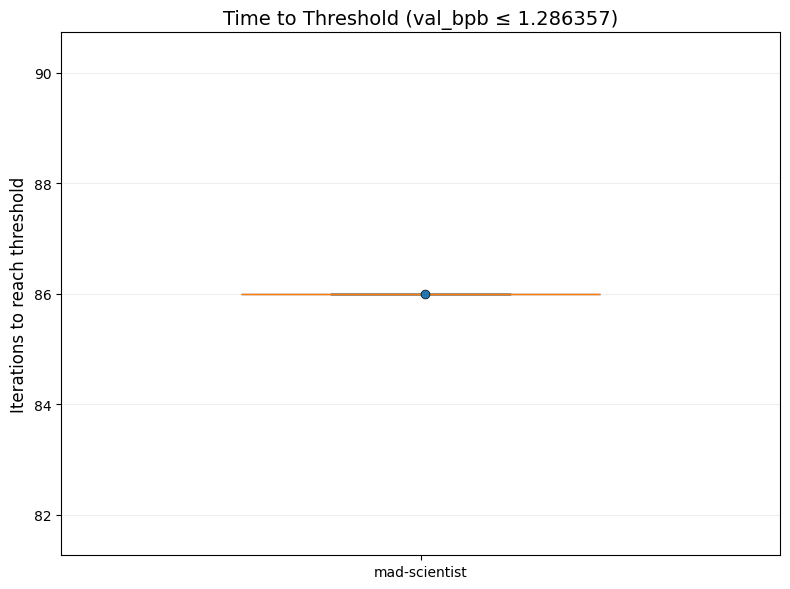

               count  mean  std   min   25%   50%   75%   max
method                                                       
mad-scientist    1.0  86.0  NaN  86.0  86.0  86.0  86.0  86.0


In [11]:
# Use the median terminal bpb of baseline as threshold (if baseline exists)
if "baseline" in methods:
    threshold = terminal[terminal["method"] == "baseline"]["terminal_bpb"].median()
else:
    threshold = terminal["terminal_bpb"].median()

print(f"Threshold: {threshold:.6f}")

# For each run, find the first iteration where best_val_bpb <= threshold
ttts = []
for (method, run_id), run_df in all_df.groupby(["method", "run_id"]):
    run_df = run_df.sort_values("iter")
    hit = run_df[run_df["best_val_bpb"] <= threshold]
    if len(hit) > 0:
        ttts.append({"method": method, "run_id": run_id, "iters_to_threshold": hit.iloc[0]["iter"]})
    else:
        ttts.append({"method": method, "run_id": run_id, "iters_to_threshold": np.nan})

ttt_df = pd.DataFrame(ttts)

fig, ax = plt.subplots(figsize=(8, 6))
data_by_method = [ttt_df[ttt_df["method"] == m]["iters_to_threshold"].dropna().values for m in methods]
bp = ax.boxplot(data_by_method, labels=methods, patch_artist=True, widths=0.5)
for patch, method in zip(bp["boxes"], methods):
    patch.set_facecolor(color_for(method))
    patch.set_alpha(0.6)

for i, method in enumerate(methods):
    vals = ttt_df[ttt_df["method"] == method]["iters_to_threshold"].dropna().values
    ax.scatter(
        np.full_like(vals, i + 1) + np.random.uniform(-0.05, 0.05, len(vals)),
        vals, color=color_for(method), s=40, zorder=5, edgecolors="black", linewidths=0.5,
    )

ax.set_ylabel("Iterations to reach threshold", fontsize=12)
ax.set_title(f"Time to Threshold (val_bpb \u2264 {threshold:.6f})", fontsize=14)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("time_to_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

print(ttt_df.groupby("method")["iters_to_threshold"].describe())

## 4. Experiment Outcome Rates

Keep / discard / crash rates by method.

Counts:
status_clean   crash  discard  keep
method                             
mad-scientist      3       71    22

Percentages:
status_clean   crash  discard  keep
method                             
mad-scientist    3.1     74.0  22.9


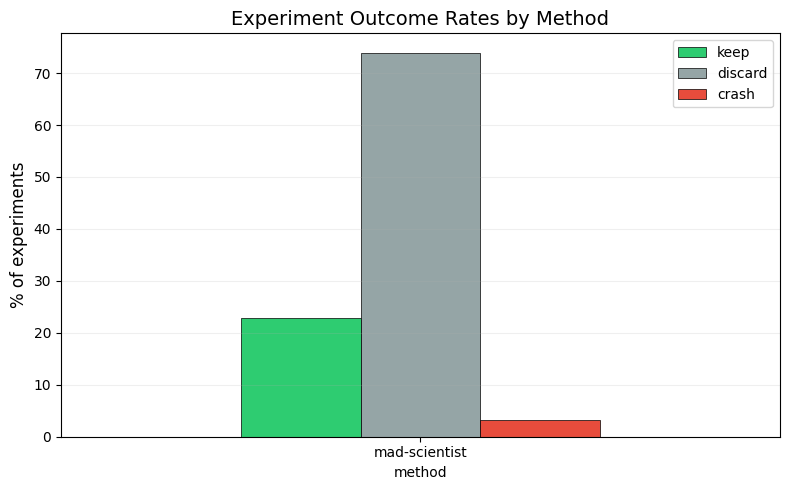

In [12]:
all_df["status_clean"] = all_df["status"].str.strip().str.lower()

rates = (
    all_df.groupby(["method", "status_clean"])
    .size()
    .unstack(fill_value=0)
)
rates_pct = rates.div(rates.sum(axis=1), axis=0) * 100

print("Counts:")
print(rates)
print("\nPercentages:")
print(rates_pct.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
rates_pct[["keep", "discard", "crash"]].plot.bar(
    ax=ax, color=["#2ecc71", "#95a5a6", "#e74c3c"], edgecolor="black", linewidth=0.5,
)
ax.set_ylabel("% of experiments", fontsize=12)
ax.set_title("Experiment Outcome Rates by Method", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("outcome_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Longest Stall (Iterations Without Improvement)

Measures how many consecutive iterations pass without a new best. Lower is better — indicates the method keeps finding improvements.

               count  mean  std   min   25%   50%   75%   max
method                                                       
mad-scientist    1.0  15.0  NaN  15.0  15.0  15.0  15.0  15.0


/var/folders/ld/h3hbldbd4_16kqkgv5fmyzph0000gn/T/ipykernel_49897/2296791202.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, labels=methods, patch_artist=True, widths=0.5)


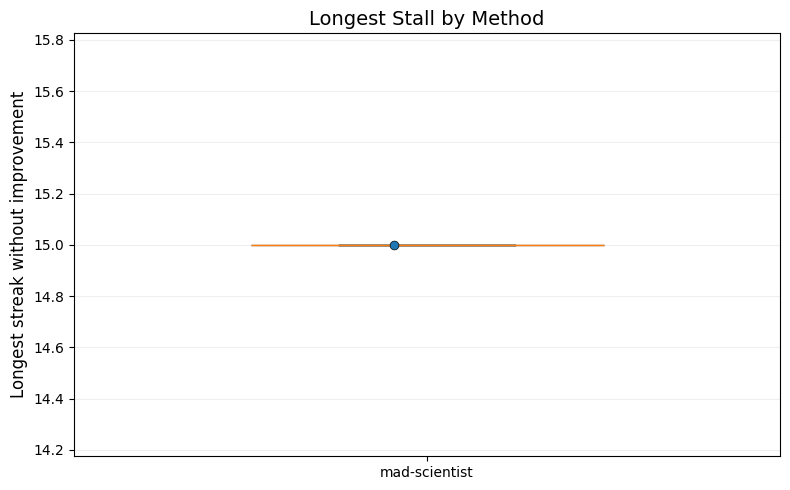

In [13]:
stalls = []
for (method, run_id), run_df in all_df.groupby(["method", "run_id"]):
    run_df = run_df.sort_values("iter")
    best_so_far = np.inf
    streak = 0
    longest = 0
    for _, row in run_df.iterrows():
        if row["best_val_bpb"] < best_so_far:
            best_so_far = row["best_val_bpb"]
            longest = max(longest, streak)
            streak = 0
        else:
            streak += 1
    longest = max(longest, streak)
    stalls.append({"method": method, "run_id": run_id, "longest_stall": longest})

stall_df = pd.DataFrame(stalls)
print(stall_df.groupby("method")["longest_stall"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
data_by_method = [stall_df[stall_df["method"] == m]["longest_stall"].values for m in methods]
bp = ax.boxplot(data_by_method, labels=methods, patch_artist=True, widths=0.5)
for patch, method in zip(bp["boxes"], methods):
    patch.set_facecolor(color_for(method))
    patch.set_alpha(0.6)

for i, method in enumerate(methods):
    vals = stall_df[stall_df["method"] == method]["longest_stall"].values
    ax.scatter(
        np.full_like(vals, i + 1, dtype=float) + np.random.uniform(-0.05, 0.05, len(vals)),
        vals, color=color_for(method), s=40, zorder=5, edgecolors="black", linewidths=0.5,
    )

ax.set_ylabel("Longest streak without improvement", fontsize=12)
ax.set_title("Longest Stall by Method", fontsize=14)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("stall.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Head-to-Head: Mad-Scientist Runs vs Original Baseline (Karpathy H100)

Compare the mad-scientist experiments (Jetson) against the original baseline run (H100).
Since hardware differs, absolute BPB values are not directly comparable — we focus on
**relative improvement**, **keep rates**, and **search efficiency**.

In [ ]:
# Load the original baseline (Karpathy H100 run)
orig = pd.read_csv("karpathy/original-baseline-results.tsv", sep="\t")
orig["val_bpb"] = pd.to_numeric(orig["val_bpb"], errors="coerce")
orig["status_clean"] = orig["status"].str.strip().str.lower()
orig["iter"] = range(1, len(orig) + 1)

# Compute running best for kept experiments (original has no best_val_bpb column)
best_so_far = np.inf
running_best = []
for _, row in orig.iterrows():
    if row["status_clean"] == "keep" and row["val_bpb"] > 0:
        best_so_far = min(best_so_far, row["val_bpb"])
    running_best.append(best_so_far)
orig["best_val_bpb"] = running_best
orig["method"] = "original-baseline"

def load_ms_run(path, label):
    df = pd.read_csv(path, sep="\t")
    df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
    df["status_clean"] = df["status"].str.strip().str.lower()
    df["iter"] = range(1, len(df) + 1)
    best_so_far = np.inf
    running_best = []
    for _, row in df.iterrows():
        if row["status_clean"] == "keep" and row["val_bpb"] > 0:
            best_so_far = min(best_so_far, row["val_bpb"])
        running_best.append(best_so_far)
    df["best_val_bpb_recomputed"] = running_best
    df["method"] = label
    return df

ms = load_ms_run("mad-scientist/results.tsv", "mad-scientist")
ms2 = load_ms_run("mad-scientist-3-11/results.tsv", "mad-scientist-3-11")

print(f"Original baseline:  {len(orig)} experiments, baseline BPB = {orig.iloc[0]['val_bpb']:.6f}")
print(f"Mad-scientist:      {len(ms)} experiments, baseline BPB = {ms.iloc[0]['val_bpb']:.6f}")
print(f"Mad-scientist-3-11: {len(ms2)} experiments, baseline BPB = {ms2.iloc[0]['val_bpb']:.6f}")

### 6a. Relative Improvement Over Time

Normalize each method's best BPB as % improvement from its own starting baseline, so we can compare across different hardware.

In [ ]:
orig_baseline_bpb = orig.iloc[0]["val_bpb"]
ms_baseline_bpb = ms.iloc[0]["val_bpb"]
ms2_baseline_bpb = ms2.iloc[0]["val_bpb"]

orig["pct_improvement"] = (orig_baseline_bpb - orig["best_val_bpb"]) / orig_baseline_bpb * 100
ms["pct_improvement"] = (ms_baseline_bpb - ms["best_val_bpb_recomputed"]) / ms_baseline_bpb * 100
ms2["pct_improvement"] = (ms2_baseline_bpb - ms2["best_val_bpb_recomputed"]) / ms2_baseline_bpb * 100

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(orig["iter"], orig["pct_improvement"],
        color="#3498db", linewidth=2, label="original-baseline (H100)")
ax.plot(ms["iter"], ms["pct_improvement"],
        color="#e74c3c", linewidth=2, label="mad-scientist (Jetson)")
ax.plot(ms2["iter"], ms2["pct_improvement"],
        color="#9b59b6", linewidth=2, label="mad-scientist-3-11 (Jetson)")

ax.set_xlabel("Iteration (experiment #)", fontsize=12)
ax.set_ylabel("% improvement from starting BPB", fontsize=12)
ax.set_title("Relative Improvement Trajectory", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("h2h_relative_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

orig_final = orig["pct_improvement"].iloc[-1]
ms_final = ms["pct_improvement"].iloc[-1]
ms2_final = ms2["pct_improvement"].iloc[-1]
print(f"Original baseline:  {orig_final:.2f}% improvement over {len(orig)} experiments")
print(f"Mad-scientist:      {ms_final:.2f}% improvement over {len(ms)} experiments")
print(f"Mad-scientist-3-11: {ms2_final:.2f}% improvement over {len(ms2)} experiments")

### 6b. Keep / Discard / Crash Rates Comparison

In [ ]:
h2h_labels = ["original-baseline", "mad-scientist", "mad-scientist-3-11"]
h2h_dfs = [orig, ms, ms2]
h2h_colors = ["#3498db", "#e74c3c", "#9b59b6"]

h2h_rates = {}
for label, df in zip(h2h_labels, h2h_dfs):
    counts = df["status_clean"].value_counts()
    total = len(df)
    h2h_rates[label] = {
        "keep": counts.get("keep", 0),
        "discard": counts.get("discard", 0),
        "crash": counts.get("crash", 0),
        "total": total,
        "keep_rate": counts.get("keep", 0) / total * 100,
        "crash_rate": counts.get("crash", 0) / total * 100,
    }

rates_df = pd.DataFrame(h2h_rates).T
print(rates_df[["keep", "discard", "crash", "total", "keep_rate", "crash_rate"]].to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(h2h_labels))
width = 0.25
ax.bar(x - width, rates_df["keep"] / rates_df["total"] * 100,
       width, color="#2ecc71", edgecolor="black", linewidth=0.5, label="keep")
ax.bar(x, rates_df["discard"] / rates_df["total"] * 100,
       width, color="#95a5a6", edgecolor="black", linewidth=0.5, label="discard")
ax.bar(x + width, rates_df["crash"] / rates_df["total"] * 100,
       width, color="#e74c3c", edgecolor="black", linewidth=0.5, label="crash")
ax.set_xticks(x)
ax.set_xticklabels(h2h_labels, rotation=15, ha="right")
ax.set_ylabel("% of experiments", fontsize=12)
ax.set_title("Outcome Rates: All Runs", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("h2h_outcome_rates.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. Search Efficiency: Experiments per Improvement

How many experiments does each method need to find one keepable improvement? Lower is better.

In [ ]:
# For each method, compute gap between consecutive keeps
for label, df in zip(h2h_labels, h2h_dfs):
    keep_iters = df[df["status_clean"] == "keep"]["iter"].values
    if len(keep_iters) > 1:
        gaps = np.diff(keep_iters)
        print(f"{label}:")
        print(f"  Keeps: {len(keep_iters)} / {len(df)} experiments")
        print(f"  Avg experiments between keeps: {gaps.mean():.1f}")
        print(f"  Median gap: {np.median(gaps):.0f}, Max gap: {gaps.max()}")
        print()

# Rolling keep rate (window of 10 experiments)
fig, ax = plt.subplots(figsize=(14, 6))
window = 10
for label, df, color in zip(h2h_labels, h2h_dfs, h2h_colors):
    is_keep = (df["status_clean"] == "keep").astype(float)
    rolling = is_keep.rolling(window, min_periods=1).mean() * 100
    ax.plot(df["iter"], rolling, color=color, linewidth=2, label=label)

ax.set_xlabel("Iteration (experiment #)", fontsize=12)
ax.set_ylabel(f"Keep rate (rolling {window}-experiment window, %)", fontsize=12)
ax.set_title("Search Efficiency Over Time", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("h2h_search_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

### 6d. Improvement per Keep

Size of each improvement step (delta BPB relative to own baseline), ordered by experiment iteration.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for label, df, base_bpb, color in zip(
    h2h_labels, h2h_dfs,
    [orig_baseline_bpb, ms_baseline_bpb, ms2_baseline_bpb],
    h2h_colors,
):
    kept = df[(df["status_clean"] == "keep") & (df["val_bpb"] > 0)].copy()
    kept["delta_pct"] = (kept["val_bpb"].shift(1) - kept["val_bpb"]) / base_bpb * 100
    kept = kept.iloc[1:]  # drop first (baseline, no delta)
    ax.bar(kept["iter"], kept["delta_pct"], color=color, alpha=0.7, width=0.8,
           edgecolor="black", linewidth=0.3, label=label)

ax.set_xlabel("Iteration (experiment #)", fontsize=12)
ax.set_ylabel("Improvement step (% of starting BPB)", fontsize=12)
ax.set_title("Size of Each Kept Improvement", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("h2h_improvement_steps.png", dpi=150, bbox_inches="tight")
plt.show()

### 6e. Summary Table

In [ ]:
summary = {}
for label, df, base_bpb in zip(
    h2h_labels, h2h_dfs,
    [orig_baseline_bpb, ms_baseline_bpb, ms2_baseline_bpb],
):
    kept = df[(df["status_clean"] == "keep") & (df["val_bpb"] > 0)]
    best_bpb = kept["val_bpb"].min()
    n_keeps = len(kept)
    n_crashes = len(df[df["status_clean"] == "crash"])
    total = len(df)

    # Longest stall
    best_so_far = np.inf
    streak, longest = 0, 0
    for _, row in df.iterrows():
        if row["status_clean"] == "keep" and row["val_bpb"] > 0 and row["val_bpb"] < best_so_far:
            best_so_far = row["val_bpb"]
            longest = max(longest, streak)
            streak = 0
        else:
            streak += 1
    longest = max(longest, streak)

    summary[label] = {
        "Total experiments": total,
        "Keeps": n_keeps,
        "Keep rate (%)": f"{n_keeps / total * 100:.1f}",
        "Crashes": n_crashes,
        "Starting BPB": f"{base_bpb:.6f}",
        "Best BPB": f"{best_bpb:.6f}",
        "Total improvement (%)": f"{(base_bpb - best_bpb) / base_bpb * 100:.2f}",
        "Improvement per experiment (%)": f"{(base_bpb - best_bpb) / base_bpb * 100 / total:.4f}",
        "Longest stall": longest,
    }

summary_df = pd.DataFrame(summary).T
print(summary_df.to_string())